# Kohonen Self-Organizing Map (SOM) for Street Risk Analysis

This notebook trains a SOM on street features (lighting, visibility, connectivity, enclosure) and analyzes how different street types correlate with **safety risk** in London boroughs.

**Key insight**: While individual features have weak correlation with crime count, feature *combinations* (identified by SOM clustering) show meaningful patterns.

## Setup & Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('C:\\Users\\maria\\Documents\\GitHub\\MaCAD26-G01-DataEncoding\\csv\\segment_risk_scores_w-id.csv')

print(f"✓ Loaded {len(df):,} street segments")
print(f"✓ Boroughs: {df['borough'].nunique()}")
print(f"\nData shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

✓ Loaded 35,978 street segments
✓ Boroughs: 5

Data shape: (35978, 10)

Columns: ['borough', 'lighting', 'visibility', 'connectivity', 'enclosure', 'public_transport_proximity_m', 'dominant_land_use_score', 'risk_score', 'risk_class', 'location_id']


In [12]:
import os

# Create output directory for SOM plots
output_dir = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen'
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Output directory ready: {output_dir}")

✓ Output directory ready: C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen


## Feature Analysis

In [13]:
# Feature summary
features = ['lighting', 'visibility', 'connectivity', 'enclosure', 'public_transport_proximity_m', 'dominant_land_use_score']

print("Feature Statistics:")
print(df[features + ['risk_score']].describe().round(3))

# Correlations with crime
print("\n" + "="*60)
print("Feature-Crime Correlations:")
print("="*60)
for feat in features:
    corr = df[feat].corr(df['risk_score'])
    print(f"{feat:15} r = {corr:7.4f}")

Feature Statistics:
        lighting  visibility  connectivity  enclosure  \
count  35978.000   35978.000     35978.000  35978.000   
mean       2.070       9.119        10.431      0.287   
std        5.956       5.583         2.326      0.150   
min        0.000       0.000         3.000      0.000   
25%        0.000       8.824         8.000      0.195   
50%        0.000       9.000        11.000      0.272   
75%        1.234       9.667        12.000      0.367   
max      163.390     180.000        17.000      1.136   

       public_transport_proximity_m  dominant_land_use_score  risk_score  
count                     35978.000                26221.000   35978.000  
mean                        110.696                   -0.619       0.640  
std                          75.332                    0.576       0.079  
min                           0.450                   -1.000       0.000  
25%                          53.940                   -1.000       0.586  
50%             

## Prepare Data for SOM

In [14]:
# Extract features and standardize
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Training data shape: {X_scaled.shape}")
print(f"Features: {', '.join(features)}")
print(f"\nScaled feature statistics:")
print(f"  Mean: {X_scaled.mean(axis=0).round(3)}")
print(f"  Std:  {X_scaled.std(axis=0).round(3)}")

Training data shape: (35978, 6)
Features: lighting, visibility, connectivity, enclosure, public_transport_proximity_m, dominant_land_use_score

Scaled feature statistics:
  Mean: [ 0. -0.  0. -0. -0. nan]
  Std:  [ 1.  1.  1.  1.  1. nan]


## Train Kohonen SOM

We use an 8×6 grid (48 clusters) to organize street segments into archetypal street types.
Similar streets cluster together, allowing us to see which street types correlate with crime.

In [15]:
print("Training SOM (8×6 grid = 48 clusters)...")

# Initialize and train SOM
som = MiniSom(x=8, y=6, input_len=len(features), sigma=1.5, learning_rate=0.5)
som.train(X_scaled, num_iteration=100, verbose=False)

print("✓ Training complete")

# Get winning neuron for each segment
winners = np.array([som.winner(x) for x in X_scaled])
df['som_x'] = winners[:, 0]
df['som_y'] = winners[:, 1]
df['som_cluster'] = df['som_x'].astype(str) + '_' + df['som_y'].astype(str)

print(f"✓ Segments assigned to {df['som_cluster'].nunique()} unique clusters")
print(f"\nCluster distribution:")
print(df['som_cluster'].value_counts().sort_index())

Training SOM (8×6 grid = 48 clusters)...
✓ Training complete
✓ Segments assigned to 48 unique clusters

Cluster distribution:
som_cluster
0_0    11004
0_1      206
0_2       38
0_3      462
0_4     1102
0_5      808
1_0      587
1_1      128
1_2      935
1_3     1672
1_4       18
1_5      179
2_0       77
2_1       29
2_2       75
2_3     2093
2_4      230
2_5      879
3_0       64
3_1       50
3_2      260
3_3      408
3_4      999
3_5      138
4_0      220
4_1      137
4_2     1890
4_3      328
4_4      489
4_5      970
5_0     1224
5_1      202
5_2      218
5_3      159
5_4      743
5_5      898
6_0      807
6_1      286
6_2      396
6_3      214
6_4     1261
6_5      466
7_0      462
7_1      336
7_2      316
7_3      104
7_4      237
7_5     1174
Name: count, dtype: int64


## Cluster Analysis: Risk by Street Type

In [17]:
# Analyze clusters
cluster_stats = []

for cluster in sorted(df['som_cluster'].unique()):
    cluster_data = df[df['som_cluster'] == cluster]
    
    cluster_stats.append({
        'cluster': cluster,
        'n_segments': len(cluster_data),
        'risk_mean': cluster_data['risk_score'].mean(),
        'risk_median': cluster_data['risk_score'].median(),
        'risk_std': cluster_data['risk_score'].std(),
        'risk_max': cluster_data['risk_score'].max(),
        'lighting_mean': cluster_data['lighting'].mean(),
        'visibility_mean': cluster_data['visibility'].mean(),
        'connectivity_mean': cluster_data['connectivity'].mean(),
        'enclosure_mean': cluster_data['enclosure'].mean(),
        'transport_mean': cluster_data['public_transport_proximity_m'].mean(),
        'land_use_mean': cluster_data['dominant_land_use_score'].mean(),
        'zero_risk_pct': (cluster_data['risk_score'] == 0).sum() / len(cluster_data) * 100,
    })

cluster_df = pd.DataFrame(cluster_stats)
cluster_df = cluster_df.sort_values('risk_mean', ascending=False)

print("\n" + "="*100)
print("TOP 15 HIGHEST RISK CLUSTERS")
print("="*100)
display(cluster_df.head(15)[['cluster', 'n_segments', 'risk_mean', 'risk_median', 
                               'lighting_mean', 'visibility_mean', 'connectivity_mean', 
                               'enclosure_mean']].round(3))

print("\n" + "="*100)
print("TOP 15 LOWEST RISK CLUSTERS")
print("="*100)
display(cluster_df.tail(15)[['cluster', 'n_segments', 'risk_mean', 'risk_median', 
                               'lighting_mean', 'visibility_mean', 'connectivity_mean', 
                               'enclosure_mean']].round(3))


TOP 15 HIGHEST RISK CLUSTERS


,cluster,n_segments,risk_mean,risk_median,lighting_mean,visibility_mean,connectivity_mean,enclosure_mean
3,0_3,462,0.773,0.768,0.767,9.932,8.706,0.513
29,4_5,970,0.756,0.754,1.346,8.970,9.844,0.252
9,1_3,1672,0.731,0.730,1.276,10.296,7.909,0.278
4,0_4,1102,0.726,0.711,0.355,9.536,10.320,0.466
5,0_5,808,0.706,0.703,1.139,9.076,7.913,0.422
11,1_5,179,0.698,0.692,0.513,1.932,9.263,0.321
35,5_5,898,0.690,0.694,0.582,9.289,13.168,0.358
28,4_4,489,0.666,0.665,0.273,10.207,11.237,0.197
34,5_4,743,0.662,0.666,1.269,9.785,12.386,0.328
23,3_5,138,0.661,0.658,2.255,6.925,11.464,0.209



TOP 15 LOWEST RISK CLUSTERS


,cluster,n_segments,risk_mean,risk_median,lighting_mean,visibility_mean,connectivity_mean,enclosure_mean
30,5_0,1224,0.572,0.573,0.218,9.184,11.757,0.214
38,6_2,396,0.570,0.569,0.856,10.418,12.389,0.299
42,7_0,462,0.565,0.572,0.405,9.269,14.667,0.238
13,2_1,29,0.562,0.572,2.738,8.658,10.759,0.216
31,5_1,202,0.562,0.562,0.173,9.103,11.743,0.281
32,5_2,218,0.557,0.563,0.471,10.875,12.330,0.374
6,1_0,587,0.556,0.556,3.656,0.814,8.094,0.116
18,3_0,64,0.553,0.555,0.200,9.518,10.797,0.164
2,0_2,38,0.545,0.533,0.086,2.504,11.579,0.136
43,7_1,336,0.538,0.548,0.542,8.987,14.333,0.235


## Key Insights: What Distinguishes High vs Low Risk Streets?

In [18]:
# Compare top 5 vs bottom 5 clusters
high_risk = cluster_df.head(5)
low_risk = cluster_df.tail(5)

print("\n" + "="*80)
print("HIGH-RISK STREET TYPES (Top 5 clusters)")
print("="*80)
print(f"Average risk_score: {high_risk['risk_mean'].mean():.2f}")
print(f"Average n_segments:  {high_risk['n_segments'].mean():.0f}")
print(f"\nTypical street profile:")
print(f"  • Enclosure (building coverage):  {high_risk['enclosure_mean'].mean():.3f}")
print(f"  • Lighting (lamps/100m):          {high_risk['lighting_mean'].mean():.2f}")
print(f"  • Connectivity (node degree):     {high_risk['connectivity_mean'].mean():.1f}")
print(f"  • Visibility (building height):   {high_risk['visibility_mean'].mean():.1f}m")
print(f"  • Transport (public transport proximity):   {high_risk['transport_mean'].mean():.1f}m")
print(f"  • Land-use (dominant land use score):   {high_risk['land_use_mean'].mean():.1f}")
print(f"  • Zero risk: {high_risk['zero_risk_pct'].mean():.0f}%")

print("\n" + "="*80)
print("LOW-RISK STREET TYPES (Bottom 5 clusters)")
print("="*80)
print(f"Average risk_score: {low_risk['risk_mean'].mean():.2f}")
print(f"Average n_segments:  {low_risk['n_segments'].mean():.0f}")
print(f"\nTypical street profile:")
print(f"  • Enclosure (building coverage):  {low_risk['enclosure_mean'].mean():.3f}")
print(f"  • Lighting (lamps/100m):          {low_risk['lighting_mean'].mean():.2f}")
print(f"  • Connectivity (node degree):     {low_risk['connectivity_mean'].mean():.1f}")
print(f"  • Visibility (building height):   {low_risk['visibility_mean'].mean():.1f}m")
print(f"  • Transport (public transport proximity):   {low_risk['transport_mean'].mean():.1f}m")
print(f"  • Land-use (dominant land use score):   {low_risk['land_use_mean'].mean():.1f}")
print(f"  • Zero risk: {low_risk['zero_risk_pct'].mean():.0f}%")

print("\n" + "="*80)
print("KEY DIFFERENCES (High Risk - Low Risk)")
print("="*80)
diff_enc = high_risk['enclosure_mean'].mean() - low_risk['enclosure_mean'].mean()
diff_lit = high_risk['lighting_mean'].mean() - low_risk['lighting_mean'].mean()
diff_conn = high_risk['connectivity_mean'].mean() - low_risk['connectivity_mean'].mean()
diff_vis = high_risk['visibility_mean'].mean() - low_risk['visibility_mean'].mean()
diff_trans = high_risk['transport_mean'].mean() - low_risk['transport_mean'].mean()
diff_land = high_risk['land_use_mean'].mean() - low_risk['land_use_mean'].mean()


print(f"  ✓ ENCLOSURE:    {diff_enc:+.3f}  (HIGH-RISK streets are MORE enclosed/covered)")
print(f"  ✓ CONNECTIVITY: {diff_conn:+.1f}   (HIGH-RISK streets are MORE connected/complex)")
print(f"  • Visibility:   {diff_vis:+.1f}  (higher buildings in high-risk)")
print(f"  • Lighting:     {diff_lit:+.2f}  (slightly more lamps in high-risk)")
print(f"  • Transport:    {diff_trans:+.1f}  (higher public transport proximity in high-risk)")
print(f"  • Land-use:      {diff_land:+.1f}  (higher dominant land use score in high-risk)")


HIGH-RISK STREET TYPES (Top 5 clusters)
Average risk_score: 0.74
Average n_segments:  1003

Typical street profile:
  • Enclosure (building coverage):  0.386
  • Lighting (lamps/100m):          0.98
  • Connectivity (node degree):     8.9
  • Visibility (building height):   9.6m
  • Transport (public transport proximity):   166.9m
  • Land-use (dominant land use score):   -0.8
  • Zero risk: 0%

LOW-RISK STREET TYPES (Bottom 5 clusters)
Average risk_score: 0.53
Average n_segments:  403

Typical street profile:
  • Enclosure (building coverage):  0.278
  • Lighting (lamps/100m):          6.16
  • Connectivity (node degree):     12.5
  • Visibility (building height):   9.9m
  • Transport (public transport proximity):   45.8m
  • Land-use (dominant land use score):   -0.5
  • Zero risk: 0%

KEY DIFFERENCES (High Risk - Low Risk)
  ✓ ENCLOSURE:    +0.108  (HIGH-RISK streets are MORE enclosed/covered)
  ✓ CONNECTIVITY: -3.6   (HIGH-RISK streets are MORE connected/complex)
  • Visibility:  

## Visualize SOM Grid: Risk Heatmap

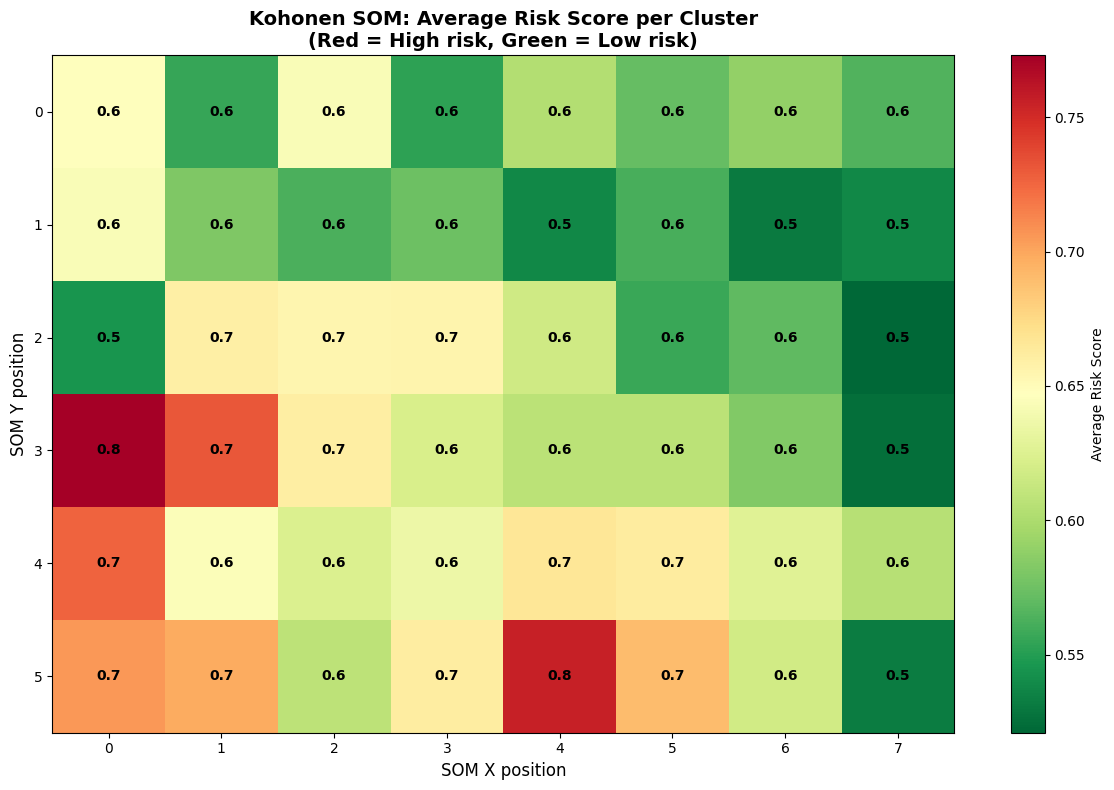

✓ Heatmap saved to C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen\som_heatmap.png


In [19]:
# Create a 2D grid showing risk_score for each SOM cell
som_grid = np.zeros((6, 8))
som_counts = np.zeros((6, 8))

for idx, row in df.iterrows():
    x, y = int(row['som_x']), int(row['som_y'])
    som_grid[y, x] += row['risk_score']
    som_counts[y, x] += 1

# Average crime per cell
som_avg = np.divide(som_grid, som_counts, where=som_counts!=0, out=np.zeros_like(som_grid))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(som_avg, cmap='RdYlGn_r', aspect='auto')

# Add values to cells
for y in range(6):
    for x in range(8):
        text = ax.text(x, y, f'{som_avg[y, x]:.1f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax.set_xticks(range(8))
ax.set_yticks(range(6))
ax.set_xticklabels(range(8))
ax.set_yticklabels(range(6))
ax.set_xlabel('SOM X position', fontsize=12)
ax.set_ylabel('SOM Y position', fontsize=12)
ax.set_title('Kohonen SOM: Average Risk Score per Cluster\n(Red = High risk, Green = Low risk)', 
             fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Average Risk Score')
plt.tight_layout()
heatmap_path = os.path.join(output_dir, 'som_heatmap.png')
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Heatmap saved to {heatmap_path}")

## Visualize SOM Feature Weights

In [20]:
# Check if there are NaN values
weights_all = som.get_weights()
print(f"Shape: {weights_all.shape}")
print(f"Any NaN values? {np.isnan(weights_all).any()}")
print(f"NaN count per feature:")
for i, feature in enumerate(['lighting', 'visibility', 'connectivity', 'enclosure', 'dominant_land_use_score', 'public_transport_proximity_m']):
    nan_count = np.isnan(weights_all[:, :, i]).sum()
    print(f"  {feature}: {nan_count}")

Shape: (8, 6, 6)
Any NaN values? False
NaN count per feature:
  lighting: 0
  visibility: 0
  connectivity: 0
  enclosure: 0
  dominant_land_use_score: 0
  public_transport_proximity_m: 0


In [21]:
# Debug: Print all weight values to see what should be displayed
feature_list = ['lighting', 'visibility', 'connectivity', 'enclosure', 'dominant_land_use_score', 'public_transport_proximity_m']
 
for idx, feature in enumerate(feature_list):
    weights = som.get_weights()[:, :, idx]
    print(f"\n{feature.upper()} - Shape: {weights.shape}")
    print(f"Min: {weights.min():.2f}, Max: {weights.max():.2f}")
    print("Values by position (x, y):")
    for y in range(weights.shape[1]):
        row = []
        for x in range(weights.shape[0]):
            val = weights[x, y]
            row.append(f"{val:6.2f}")
        print(f"y={y}: " + "  ".join(row))
    print()
 


LIGHTING - Shape: (8, 6)
Min: -0.42, Max: 0.85
Values by position (x, y):
y=0:  -0.11   -0.24   -0.10   -0.42   -0.37   -0.35   -0.34   -0.34
y=1:   0.05   -0.35   -0.01   -0.33   -0.32   -0.30   -0.31   -0.26
y=2:  -0.36   -0.25   -0.27   -0.29   -0.32   -0.26   -0.10    0.09
y=3:  -0.28   -0.06   -0.12   -0.14   -0.18   -0.01    0.26    0.29
y=4:  -0.30   -0.01   -0.01   -0.25   -0.19   -0.01    0.15    0.42
y=5:  -0.19   -0.20   -0.19   -0.08   -0.12   -0.18    0.30    0.85


VISIBILITY - Shape: (8, 6)
Min: -1.06, Max: 0.38
Values by position (x, y):
y=0:  -0.32   -1.06   -0.89   -0.14   -0.14   -0.03   -0.02   -0.02
y=1:  -0.35   -0.57   -0.43   -0.09    0.02   -0.01   -0.02   -0.03
y=2:  -0.64   -0.60   -0.28    0.01    0.11    0.10    0.06    0.04
y=3:  -0.12    0.01   -0.01    0.07    0.06   -0.01    0.08    0.21
y=4:  -0.01   -0.41   -0.43   -0.08   -0.03    0.05    0.38    0.27
y=5:  -0.24   -0.66   -1.04   -0.29   -0.04   -0.03    0.18    0.23


CONNECTIVITY - Shape: (8, 6)


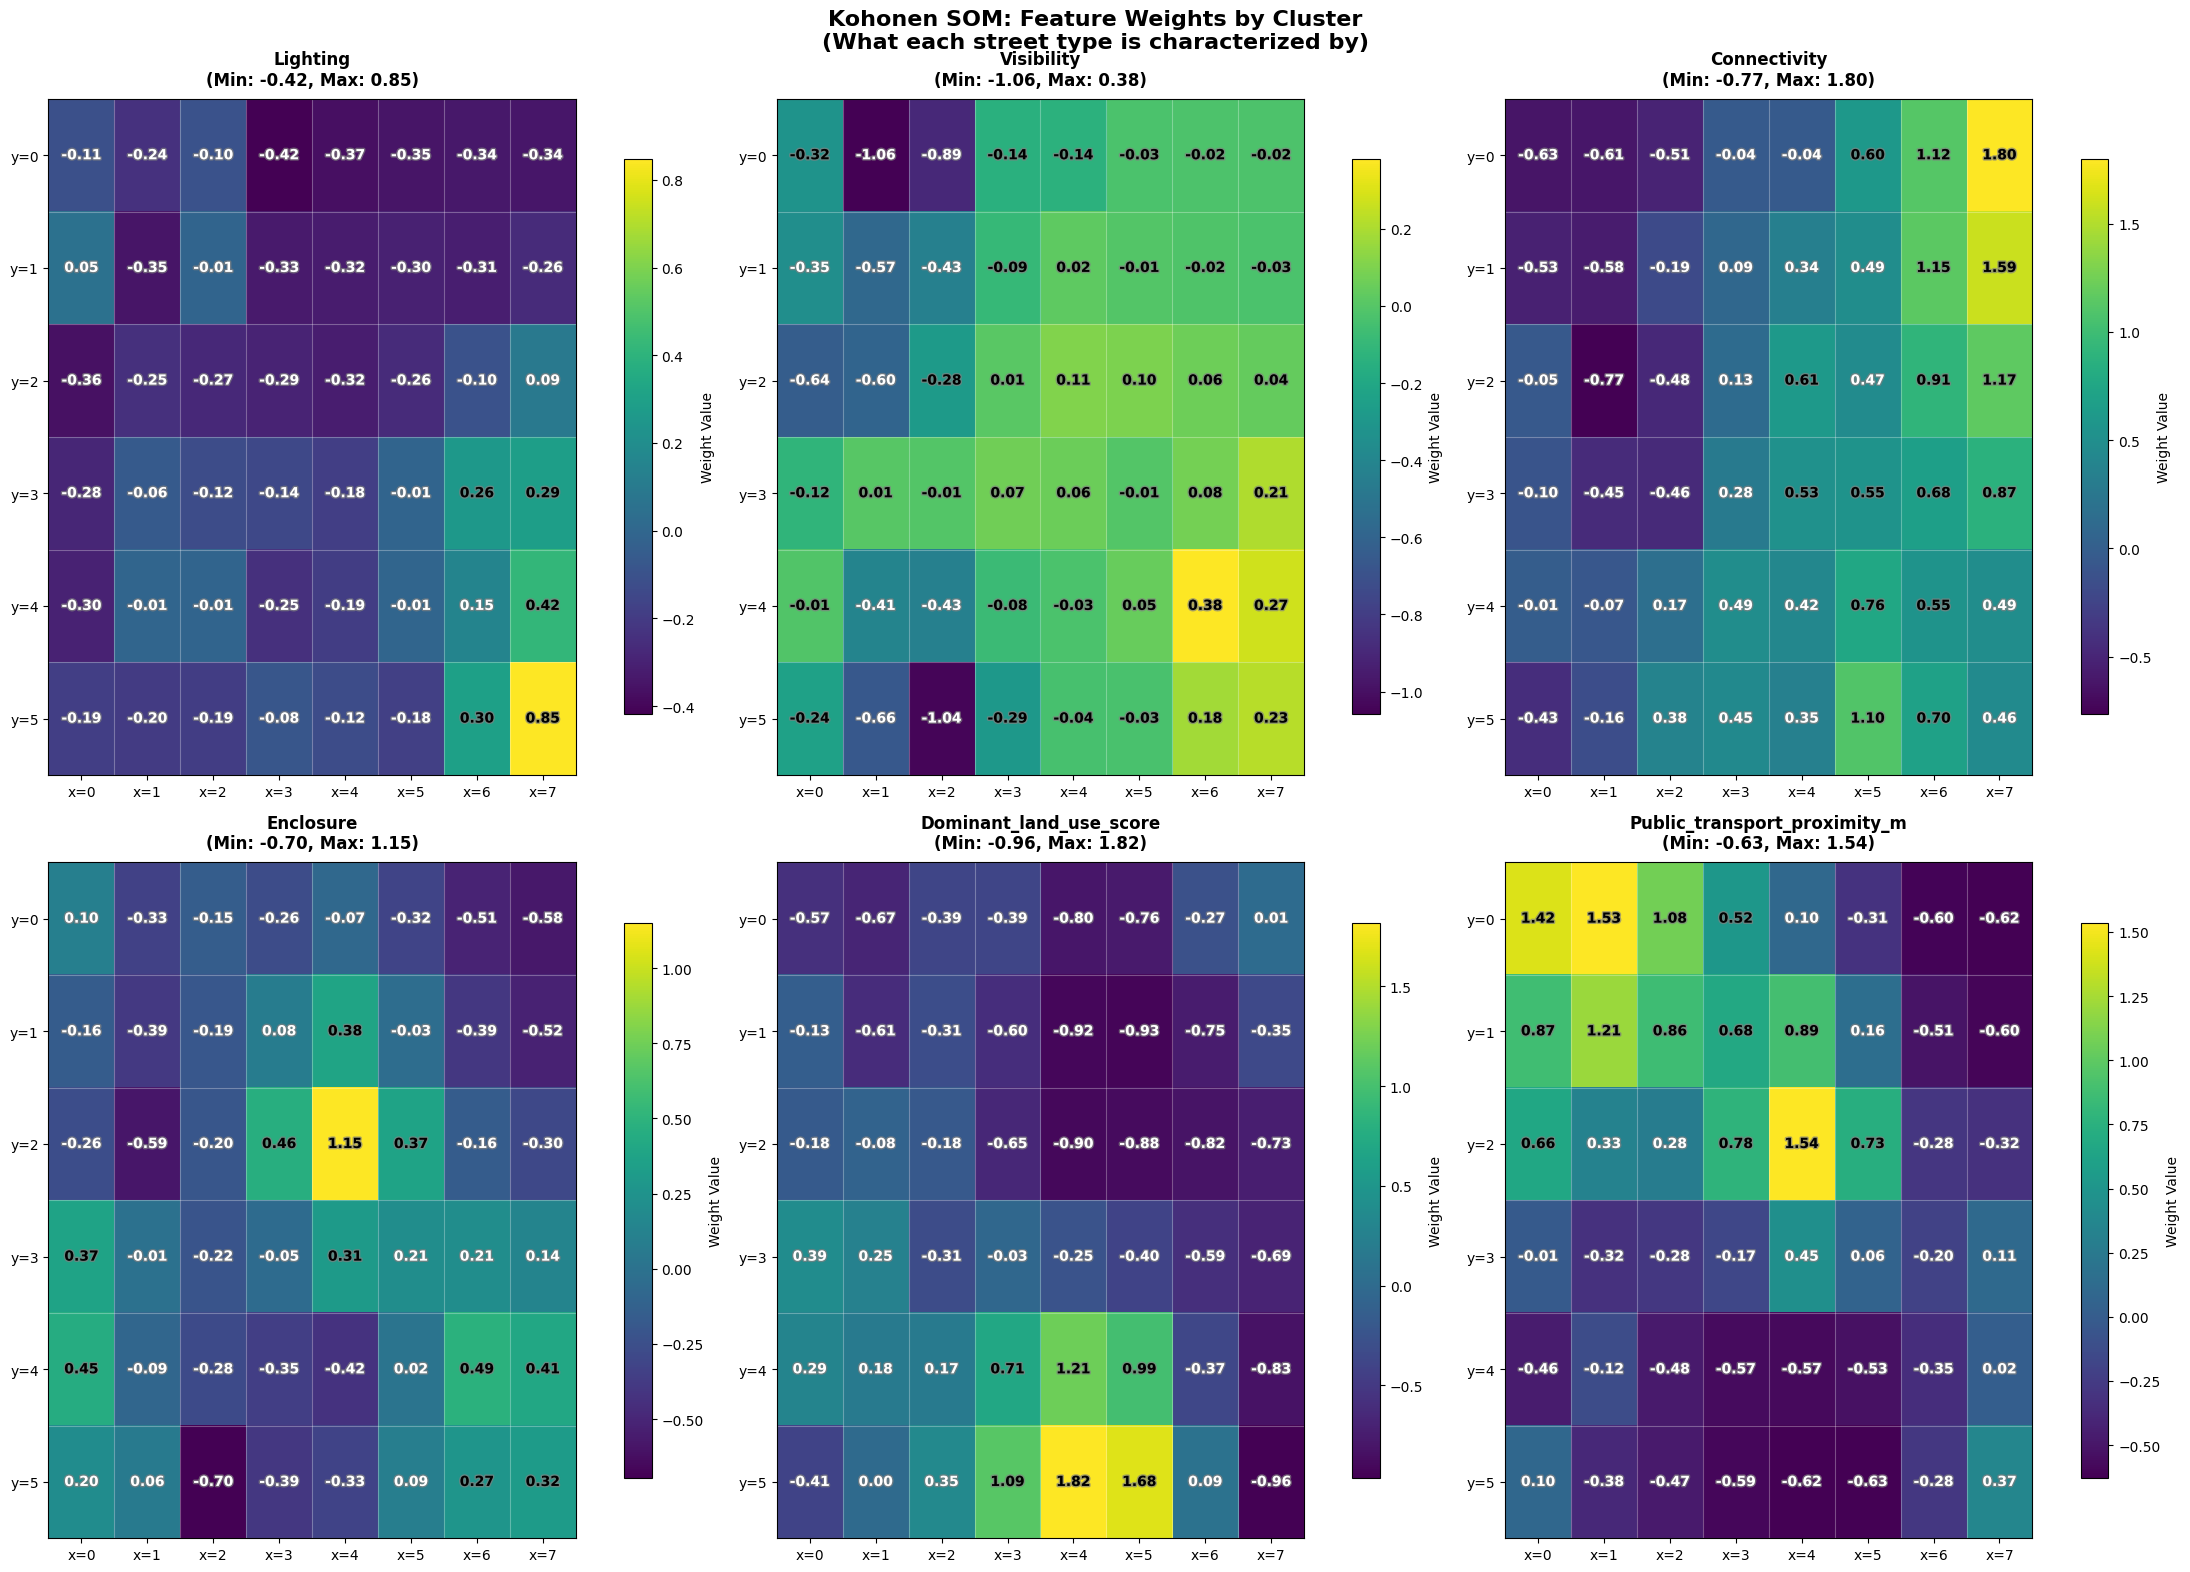

✓ Feature weights saved to C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen\som_weights.png


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(22, 16))
fig.suptitle('Kohonen SOM: Feature Weights by Cluster\n(What each street type is characterized by)', 
             fontsize=16, fontweight='bold', y=0.98)

feature_list = ['lighting', 'visibility', 'connectivity', 'enclosure', 'dominant_land_use_score', 'public_transport_proximity_m']

for idx, (ax, feature) in enumerate(zip(axes.flat, feature_list)):
    # Get weights for this feature and TRANSPOSE
    weights = som.get_weights()[:, :, idx].T  # Now shape is (6, 8) for imshow
    
    # Draw heatmap
    im = ax.imshow(weights, cmap='viridis', aspect='auto', interpolation='nearest')
    
    # Add text values - iterate through actual dimensions
    for y in range(weights.shape[0]):  # y: 0-5 (6 rows)
        for x in range(weights.shape[1]):  # x: 0-7 (8 columns)
            val = weights[y, x]
            
            # Determine text color based on normalized brightness
            norm_val = (val - weights.min()) / (weights.max() - weights.min() + 1e-10)
            text_color = "white" if norm_val < 0.5 else "black"
            
            # Add text with proper styling
            ax.text(x, y, f'{val:.2f}', 
                   ha="center", va="center", 
                   color=text_color, 
                   fontsize=10, 
                   fontweight='bold',
                   path_effects=[path_effects.withStroke(linewidth=2, 
                                                         foreground='gray', 
                                                         alpha=0.7)])
    
    # Styling
    ax.set_xticks(range(weights.shape[1]))
    ax.set_yticks(range(weights.shape[0]))
    ax.set_xticklabels([f'x={i}' for i in range(weights.shape[1])], fontsize=10)
    ax.set_yticklabels([f'y={i}' for i in range(weights.shape[0])], fontsize=10)
    ax.set_title(f'{feature.capitalize()}\n(Min: {weights.min():.2f}, Max: {weights.max():.2f})', 
                fontweight='bold', fontsize=12, pad=10)
    
    # Add colorbar with proper spacing to avoid text overlap
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.08)
    cbar.set_label('Weight Value', fontsize=10)
    
    # Grid for better readability
    for i in range(weights.shape[1] + 1):
        ax.axvline(i - 0.5, color='white', linestyle='-', linewidth=0.8, alpha=0.3)
    for j in range(weights.shape[0] + 1):
        ax.axhline(j - 0.5, color='white', linestyle='-', linewidth=0.8, alpha=0.3)

plt.tight_layout()
weights_path = os.path.join(output_dir, 'som_weights.png')
plt.savefig(weights_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Feature weights saved to {weights_path}")

In [23]:
# First, check which neurons have segments assigned
print("Checking neuron occupancy...")
neuron_counts = np.zeros((6, 8))
for idx, row in df.iterrows():
    x, y = int(row['som_x']), int(row['som_y'])
    neuron_counts[y, x] += 1

used_neurons = np.sum(neuron_counts > 0)
total_neurons = 8 * 6
print(f"Neurons with segments: {used_neurons}/{total_neurons}")
print(f"\nSegments per neuron:")
print(neuron_counts.astype(int))

Checking neuron occupancy...
Neurons with segments: 48/48

Segments per neuron:
[[11004   587    77    64   220  1224   807   462]
 [  206   128    29    50   137   202   286   336]
 [   38   935    75   260  1890   218   396   316]
 [  462  1672  2093   408   328   159   214   104]
 [ 1102    18   230   999   489   743  1261   237]
 [  808   179   879   138   970   898   466  1174]]


## Visualize Distribution of Clusters by Crime

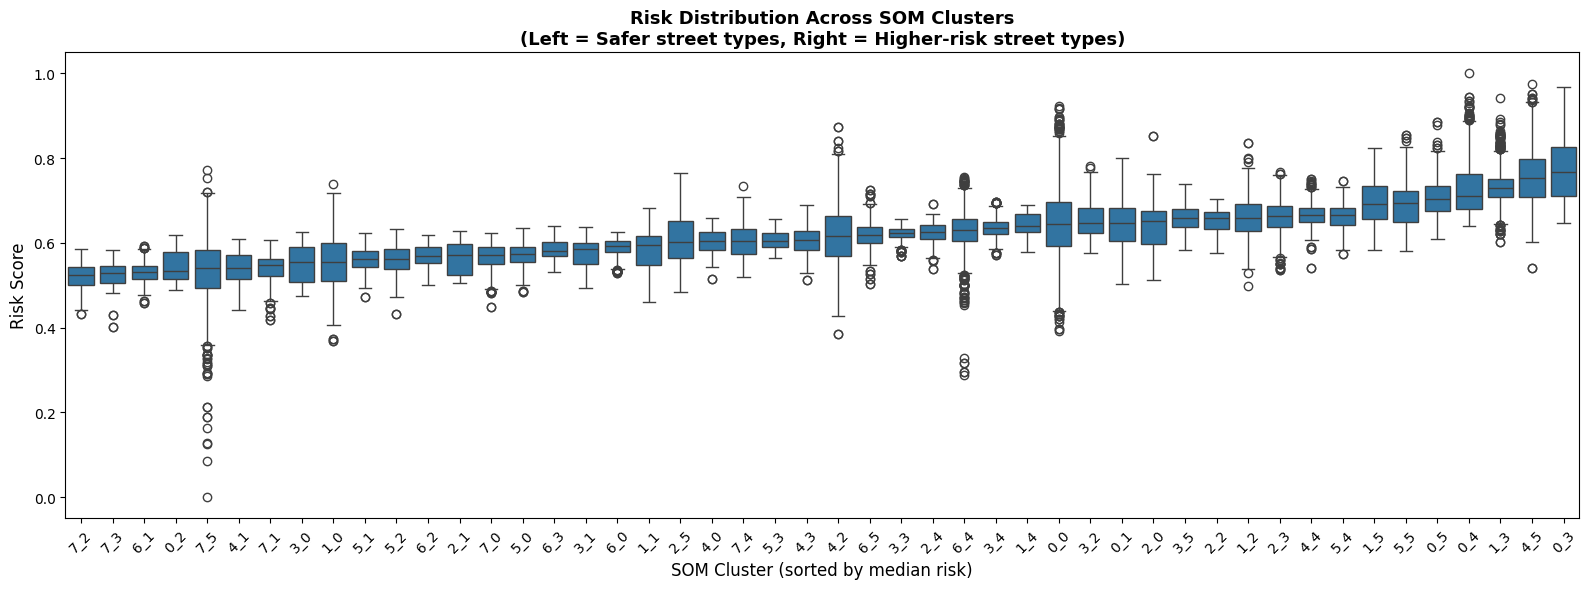

✓ Box plot saved to C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen\som_clusters_boxplot.png


In [24]:
# Box plot of risk by SOM cluster
fig, ax = plt.subplots(figsize=(16, 6))

# Sort clusters by median risk to ensure left-to-right ordering from safer to riskier
cluster_order = cluster_df.sort_values('risk_median')['cluster'].tolist()

sns.boxplot(data=df, x='som_cluster', y='risk_score', order=cluster_order, ax=ax)
ax.set_xlabel('SOM Cluster (sorted by median risk)', fontsize=12)
ax.set_ylabel('Risk Score', fontsize=12)
ax.set_title('Risk Distribution Across SOM Clusters\n(Left = Safer street types, Right = Higher-risk street types)', 
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
boxplot_path = os.path.join(output_dir, 'som_clusters_boxplot.png')
plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Box plot saved to {boxplot_path}")

## Geographic Distribution of Street Types

In [25]:
# Show which boroughs have which street types
print("\nSOM Cluster Distribution by Borough:")
print("="*100)

cluster_by_borough = pd.crosstab(df['borough'], df['som_cluster'], margins=True)
print(cluster_by_borough)


SOM Cluster Distribution by Borough:
som_cluster                                    0_0  0_1  0_2  0_3   0_4  0_5  \
borough                                                                        
City of Westminster, London, UK                470   42    6  307   666  295   
London Borough of Hackney, London, UK          250   42   12   41   145  154   
London Borough of Islington, London, UK        217   30    2   49   123  200   
London Borough of Southwark, London, UK       9757    0    0    0     0    0   
London Borough of Tower Hamlets, London, UK    310   92   18   65   168  159   
All                                          11004  206   38  462  1102  808   

som_cluster                                  1_0  1_1  1_2   1_3  ...  6_3  \
borough                                                           ...        
City of Westminster, London, UK              195   18  198   351  ...   50   
London Borough of Hackney, London, UK         72   30  222   382  ...   62   
London Bo

## Export Results

In [ ]:
# Save full dataset with SOM assignments
# Use only columns that exist in the dataframe
available_cols = ['borough', 'location_id', 'lighting', 'visibility', 
                  'connectivity', 'enclosure', 'risk_score', 'dominant_land_use_score', 'public_transport_proximity_m', 
                  'som_cluster', 'som_x', 'som_y']

df_export = df[available_cols].copy()
project_root = os.getcwd()
if not os.path.isdir(os.path.join(project_root, 'csv')) and os.path.isdir(os.path.join(os.path.dirname(project_root), 'csv')):
    project_root = os.path.dirname(project_root)

csv_dir = os.path.join(project_root, 'csv')
os.makedirs(csv_dir, exist_ok=True)

df_export.to_csv(os.path.join(csv_dir, 'features_with_som_clusters.csv'), index=False)
print(f"✓ Saved {len(df_export):,} segments with SOM assignments")

# Save cluster statistics
cluster_df.to_csv(os.path.join(csv_dir, 'som_cluster_statistics.csv'), index=False)
print(f"✓ Saved cluster statistics (48 clusters)")

print("\n✓ Export complete!")

✓ Saved 35,978 segments with SOM assignments
✓ Saved cluster statistics (48 clusters)

✓ Export complete!
